# I. Monthly Sales Trend Analysis

Menganalisis tren penjualan bulanan untuk mengidentifikasi pola perubahan performa penjualan dari waktu
ke waktu serta mengidentifikasi potensi seasonality pada transaksi e-commerce.

In [1]:
import pandas as pd

df = pd.read_csv("../data/global_ecommerce_clean.csv")

df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method,Year,Month,Month_Name,Profit_Margin
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery,2023,1,January,0.418787
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery,2023,1,January,0.266833
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card,2023,1,January,0.171788
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal,2023,1,January,0.250285
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card,2023,1,January,0.239515


In [3]:
# Memastikan Order_Date tetap tipe datetime

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [4]:
# Agregasi Sales Perbulan

monthly_sales = df.groupby(
    df["Order_Date"].dt.to_period("M")
)["Total_Sales"].sum()

monthly_sales.head()

Order_Date
2023-01    11275.20
2023-02    16943.67
2023-03    16056.45
2023-04    12185.00
2023-05     8218.47
Freq: M, Name: Total_Sales, dtype: float64

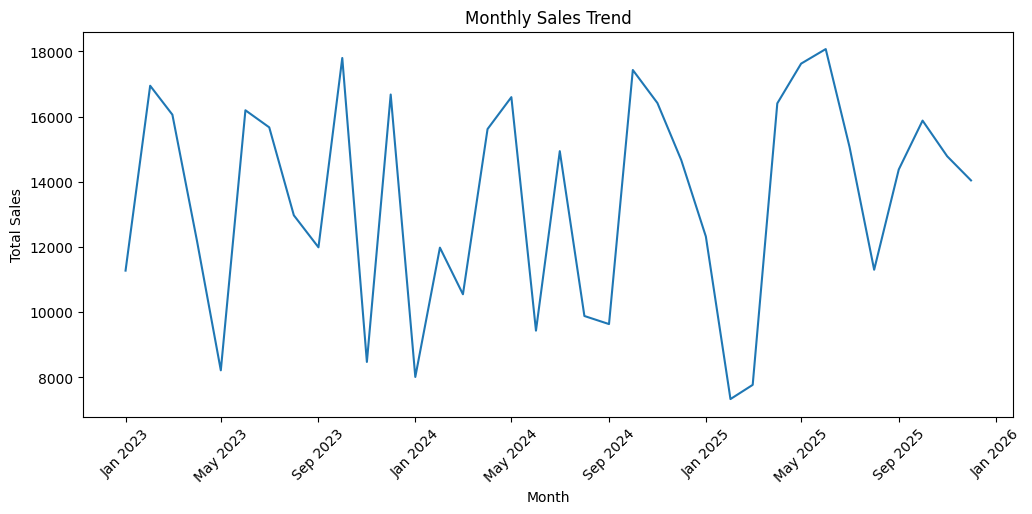

In [15]:
# Visuaslisai Tren Sales

import matplotlib.pyplot as plt

monthly_sales.index = pd.to_datetime(monthly_sales.index.astype(str))

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.gca().xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter('%b %Y')
)

plt.xticks(rotation=45)

plt.show()

Tren penjualan bulanan selama periode 2023 hingga 2025 menunjukkan fluktuasi yang cukup signifikan tanpa pola pertumbuhan yang konsisten dari waktu ke waktu. Beberapa lonjakan penjualan terlihat terjadi pada pertengahan tahun, sementara penurunan tajam terjadi pada awal tahun 2025 sebelum kembali meningkat pada bulan-bulan berikutnya. Pola ini mengindikasikan adanya kemungkinan pengaruh faktor musiman terhadap performa penjualan dibandingkan tren pertumbuhan jangka panjang yang stabil.

# II. Monthly Profit Trend Analysis

Menganalisis tren profit bulanan untuk memahami perubahan tingkat keuntungan dari waktu ke waktu serta membandingkan pola profitabilitas terhadap tren penjualan.

In [ ]:
# Total Profit per Bulan

monthly_profit = df.groupby(
    df["Order_Date"].dt.to_period("M")
)["Profit"].sum()

monthly_profit.head()

Order_Date
2023-01    3573.01
2023-02    5980.06
2023-03    5718.77
2023-04    3994.25
2023-05    2591.86
Freq: M, Name: Profit, dtype: float64

In [13]:
# Konversi Index Agar Label Rapi

import pandas as pd

monthly_profit.index = pd.to_datetime(monthly_profit.index)

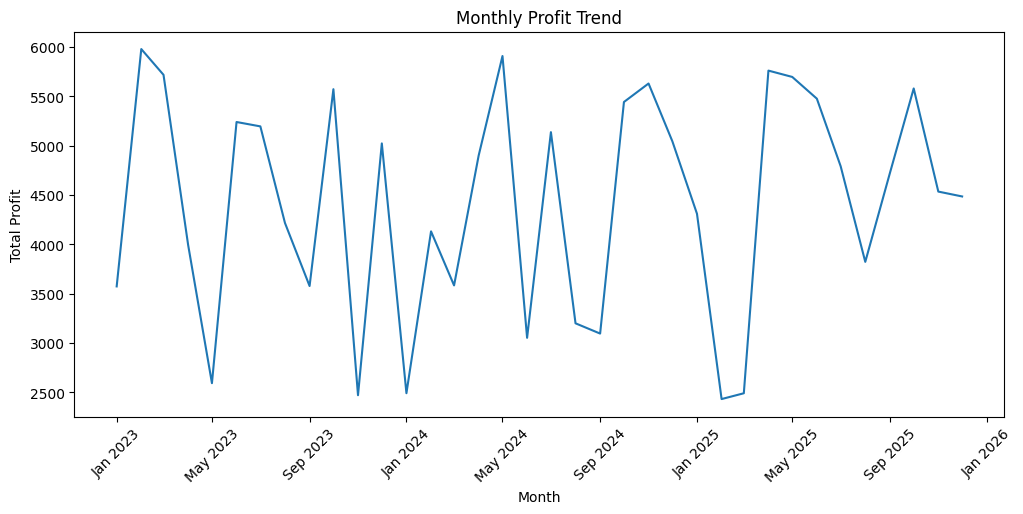

In [14]:
# Visualisasi Profit Trend

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12,5))
plt.plot(monthly_profit.index, monthly_profit.values)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit")

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

plt.xticks(rotation=45)

plt.show()

Tren profit bulanan selama periode 2023 hingga 2025 menunjukkan fluktuasi yang cukup signifikan tanpa pola pertumbuhan jangka panjang yang konsisten. Penurunan profit paling tajam terjadi pada awal tahun 2025 yang sejalan dengan penurunan performa penjualan pada periode yang sama. Sebaliknya, peningkatan profit cenderung terjadi pada pertengahan tahun di beberapa periode observasi, yang mengindikasikan kemungkinan adanya pola musiman dalam profitabilitas transaksi. Hal ini menunjukkan bahwa performa keuntungan tidak hanya dipengaruhi oleh volume penjualan tetapi juga oleh faktor lain seperti strategi diskon dan biaya operasional.

# III. Sales VS Profit by Product Category

Menganalisa kontribusi penjualan dan profit pada setiap kategori produk untuk mengidentifikasi kategori
dengan performa terbaik serta kategori produk dengan efisiensi profitabilitas rendah.

In [ ]:
# Total Sales per Category

sales_by_category = df.groupby("Product_Category")["Total_Sales"].sum().sort_values(ascending=False)

sales_by_category

Product_Category
Furniture                 256274.68
Technology                139518.22
Clothing & Accessories     69375.63
Office Supplies            19390.81
Name: Total_Sales, dtype: float64

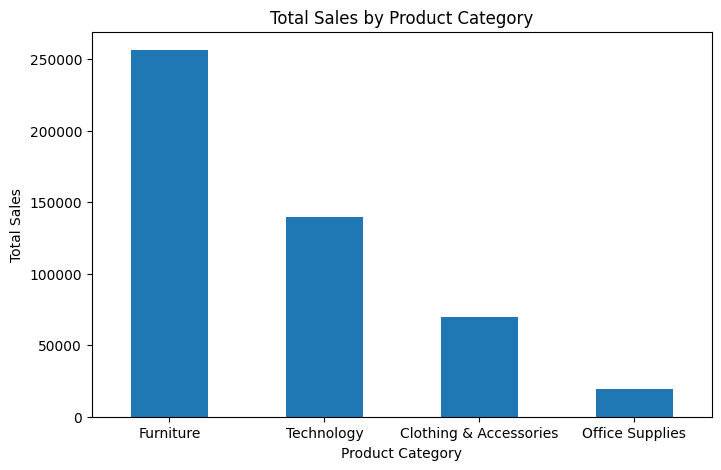

In [25]:
# Visualisasi Sales per Category

sales_by_category.plot(kind="bar", figsize=(8,5))

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.show()

In [ ]:
# Total Profit per Category

profit_by_category = df.groupby("Product_Category")["Profit"].sum().sort_values(ascending=False)

profit_by_category

Product_Category
Furniture                 81171.57
Technology                48268.65
Clothing & Accessories    26112.94
Office Supplies            3319.16
Name: Profit, dtype: float64

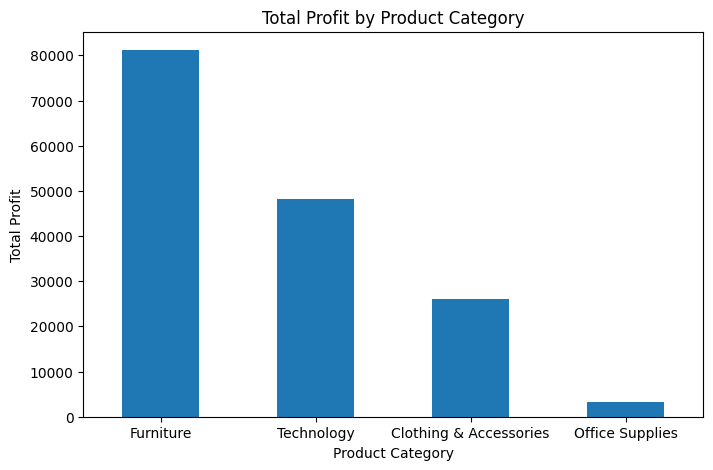

In [27]:
# Visualisasi Profit per Category

profit_by_category.plot(kind="bar", figsize=(8,5))

plt.title("Total Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=0)

plt.show()

In [ ]:
# Total Profit Margin per Category

margin_by_category = df.groupby("Product_Category")["Profit_Margin"].mean().sort_values(ascending=False)

margin_by_category

Product_Category
Clothing & Accessories    0.292293
Technology                0.286767
Furniture                 0.271311
Office Supplies          -0.040083
Name: Profit_Margin, dtype: float64

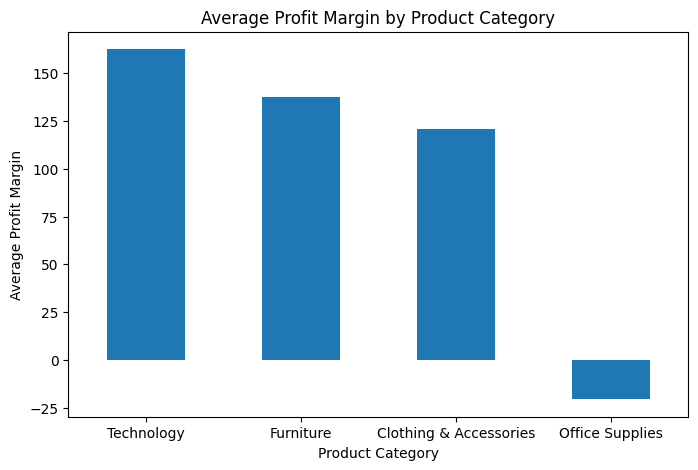

In [29]:
# Visualisasi Profit Margin per Category

margin_by_category.plot(kind="bar", figsize=(8,5))

plt.title("Average Profit Margin by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Profit Margin")

plt.xticks(rotation=0)

plt.show()

Analisis profit margin menunjukkan bahwa kategori Clothing & Accessories memiliki tingkat efisiensi profitabilitas tertinggi dengan margin rata-rata sekitar 29%, meskipun kontribusi total penjualannya relatif lebih kecil dibandingkan kategori utama lainnya. Kategori Technology juga menunjukkan kombinasi yang kuat antara kontribusi penjualan yang tinggi dan margin yang sehat, sehingga berpotensi menjadi salah satu sumber pertumbuhan profit yang strategis bagi perusahaan. Sementara itu, kategori Furniture memberikan kontribusi terbesar terhadap total penjualan dan profit perusahaan, namun memiliki tingkat margin yang sedikit lebih rendah dibandingkan dua kategori lainnya, yang mengindikasikan adanya kemungkinan biaya operasional seperti logistik atau diskon yang lebih tinggi. Sebaliknya, kategori Office Supplies menunjukkan margin negatif secara rata-rata, yang mengindikasikan adanya ketidakefisienan pada struktur biaya atau strategi diskon sehingga berpotensi menurunkan profitabilitas secara keseluruhan.

Berdasarkan benchmark umum pada industri retail dan e-commerce, margin keuntungan di atas 20% dapat dikategorikan sebagai tingkat profitabilitas yang sehat. Dalam dataset ini, kategori Clothing & Accessories, Technology, dan Furniture menunjukkan margin yang berada pada kisaran 27%–29% sehingga dapat dianggap memiliki performa profitabilitas yang kuat. Sebaliknya, kategori Office Supplies menunjukkan margin negatif, yang mengindikasikan adanya ketidakefisienan dalam struktur biaya atau strategi penetapan harga pada kategori tersebut dan berpotensi menurunkan kinerja profit secara keseluruhan.

# IV. Sales VS Profit per Region

Menganalisis kontribusi penjualan dan profit pada setiap region untuk mengidentifikasi wilayah dengan performa terbaik serta potensi ketidakefisienan operasional antar wilayah geografis.

In [ ]:
# Total Sales by Region

sales_by_region = df.groupby("Region")["Total_Sales"].sum().sort_values(ascending=False)

sales_by_region

Region
Europe                  137006.20
North America           133876.38
Asia Pacific            121707.51
South America            46051.13
Middle East & Africa     45918.12
Name: Total_Sales, dtype: float64

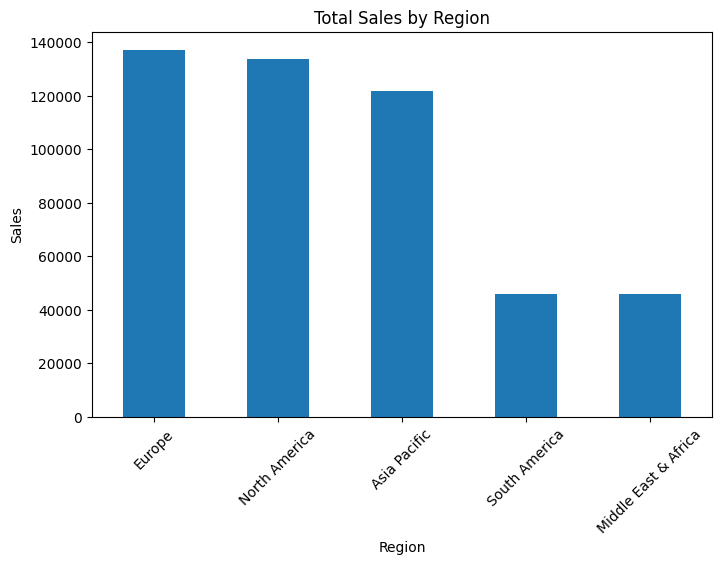

In [38]:
# Visualisasi Sales by Region

sales_by_region.plot(kind="bar" , figsize=(8,5))

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

In [39]:
# Total Profit by Region

profit_by_region = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

profit_by_region

Region
Europe                  45672.16
North America           45250.09
Asia Pacific            39116.61
South America           14680.98
Middle East & Africa    14152.48
Name: Profit, dtype: float64

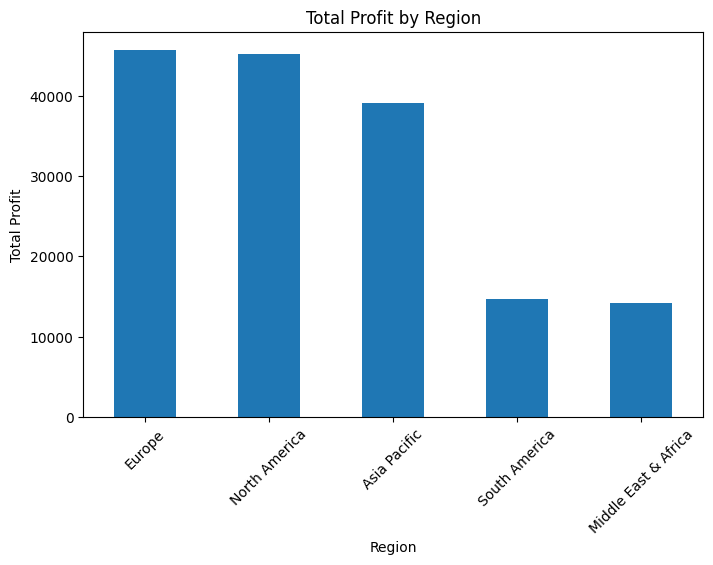

In [40]:
# Visualisasi Profit by Region

profit_by_region.plot(kind="bar", figsize=(8,5))

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)

plt.show()


In [42]:
# Total Profit Margin by Region

margin_by_region = df.groupby("Region")["Profit_Margin"].mean().sort_values(ascending=False)

margin_by_region

Region
North America           0.244591
Europe                  0.229894
Asia Pacific            0.167120
Middle East & Africa    0.159913
South America           0.121107
Name: Profit_Margin, dtype: float64

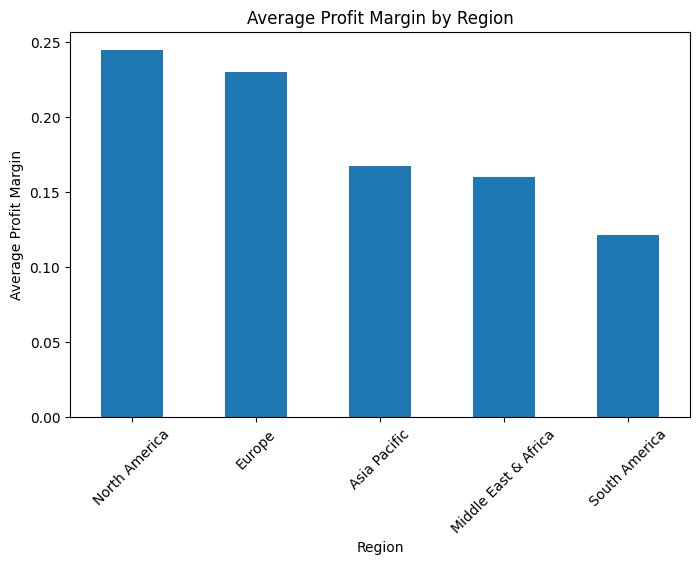

In [44]:
# Visualisasi Total Profit Margin by Region

margin_by_region.plot(kind="bar" , figsize=(8,5))

plt.title("Average Profit Margin by Region")
plt.xlabel("Region")
plt.ylabel("Average Profit Margin")

plt.xticks(rotation=45)

plt.show()

In [46]:
# Shipping Cost by Region

shipping_by_region = df.groupby("Region")["Shipping_Cost"].mean().sort_values(ascending=False)

shipping_by_region

Region
Middle East & Africa    15.995385
South America           15.444241
Asia Pacific            14.482981
Europe                  12.304911
North America           10.046419
Name: Shipping_Cost, dtype: float64

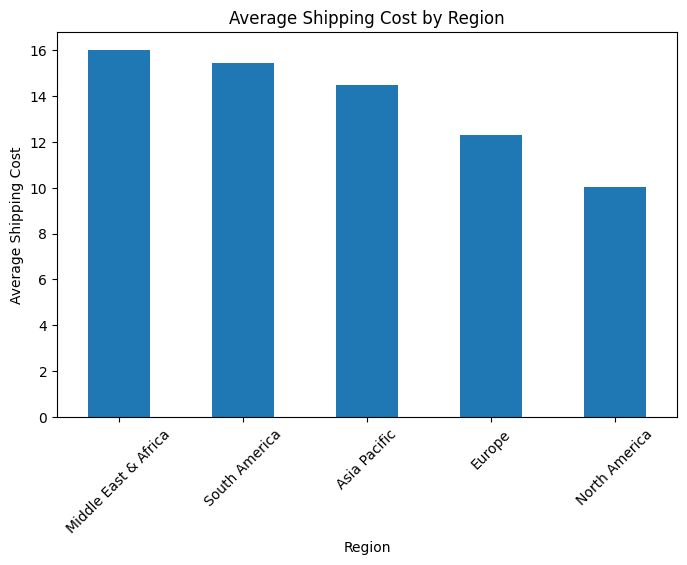

In [49]:
# Visualisasi Shipping Cost by Region

shipping_by_region.plot(kind="bar", figsize=(8,5))

plt.title("Average Shipping Cost by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Cost")

plt.xticks(rotation=45)

plt.show()



In [51]:
# Average Order Value by Region

aov_by_region = df.groupby("Region")["Total_Sales"].mean().sort_values(ascending=False)

aov_by_region


Region
Europe                  272.378131
South America           241.105393
Asia Pacific            234.052904
North America           231.620035
Middle East & Africa    220.760192
Name: Total_Sales, dtype: float64

Analisis regional menunjukkan bahwa North America memiliki tingkat profit margin tertinggi yang didukung oleh biaya pengiriman rata-rata paling rendah dibandingkan region lainnya. Europe juga menunjukkan performa yang kuat dengan nilai transaksi rata-rata tertinggi serta kontribusi penjualan yang besar. Sebaliknya, region Asia Pacific, South America, serta Middle East & Africa menunjukkan margin keuntungan yang lebih rendah yang berkorelasi dengan tingginya biaya pengiriman relatif terhadap nilai transaksi. Middle East & Africa memiliki kombinasi rata-rata nilai transaksi terendah dan biaya pengiriman tertinggi sehingga menghasilkan efisiensi profitabilitas yang lebih rendah dibandingkan region lainnya. Temuan ini menunjukkan bahwa optimasi strategi logistik berpotensi meningkatkan profitabilitas pada region-region tersebut.

# V. Discount VS Profit Relationship

Menganalisis hubungan antara tingkat diskon dan profitabilitas transaksi untuk memahami apakah strategi diskon berdampak positif atau negatif terhadap keuntungan perusahaan.

In [ ]:
# Average Profit by Discount Level

profit_by_discount = df.groupby("Discount_Percent")["Profit"].mean()

profit_by_discount

Discount_Percent
0     100.805726
5      94.526947
10     74.339752
15     52.894551
20     55.061420
25     38.337015
30     40.462222
Name: Profit, dtype: float64

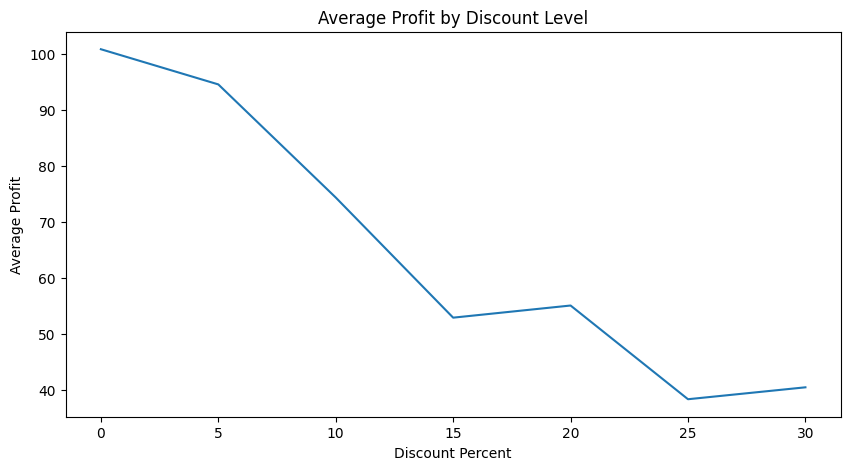

In [55]:
# Visualisasi Profit by Discount Level

profit_by_discount.plot(figsize=(10,5))

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount Percent")
plt.ylabel("Average Profit")

plt.show()


In [54]:
# Average Profit Margin by Discount Level

margin_by_discount = df.groupby("Discount_Percent")["Profit_Margin"].mean()

margin_by_discount

Discount_Percent
0     0.264199
5     0.243819
10    0.197577
15    0.124949
20    0.094786
25    0.066128
30    0.081671
Name: Profit_Margin, dtype: float64

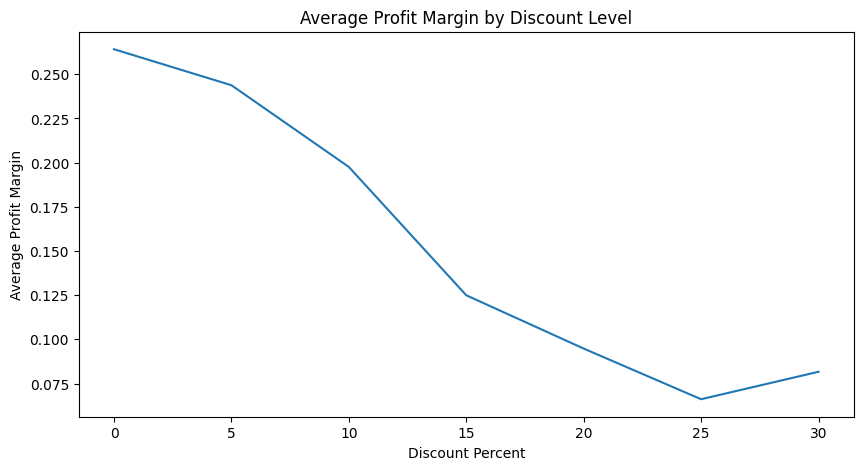

In [57]:
# Visualisasi Average Profit Margin by Discount Level

margin_by_discount.plot(figsize=(10,5))

plt.title("Average Profit Margin by Discount Level")
plt.xlabel("Discount Percent")
plt.ylabel("Average Profit Margin")

plt.show()

plt.show()

In [59]:
# Loss Distribution by Discount

loss_by_discount = df[df["Profit"] < 0]["Discount_Percent"].value_counts().sort_index()

loss_by_discount

Discount_Percent
0     56
5     49
10    59
15    65
20    26
25    15
30     2
Name: count, dtype: int64

Hasil analisis menunjukkan bahwa strategi diskon memiliki dampak langsung terhadap efisiensi profitabilitas transaksi. Rata-rata profit dan profit margin menurun secara konsisten seiring meningkatnya tingkat diskon, dengan penurunan paling signifikan terjadi setelah diskon melebihi 15%. Meskipun transaksi tanpa diskon juga menunjukkan sejumlah kasus kerugian, temuan sebelumnya mengindikasikan bahwa faktor biaya operasional seperti shipping cost memiliki pengaruh yang lebih dominan terhadap kerugian dibandingkan diskon itu sendiri. Berdasarkan pola tersebut, rentang diskon hingga 10% masih dapat dianggap optimal untuk menjaga keseimbangan antara peningkatan volume penjualan dan efisiensi margin keuntungan, sementara diskon di atas 15% sebaiknya diterapkan secara selektif pada kategori atau region tertentu.

# VI. Customer Segment Perfomance Analysis

Menganalisis kontribusi penjualan dan profit berdasarkan segmen pelanggan untuk mengidentifikasi kelompok pelanggan dengan tingkat profitabilitas tertinggi.

In [ ]:
# Total Sales by Customer Segment

sales_by_segment = df.groupby("Customer_Segment")["Total_Sales"].sum().sort_values(ascending=False)

sales_by_segment

Customer_Segment
Consumer       256287.74
Corporate      146050.39
Home Office     82221.21
Name: Total_Sales, dtype: float64

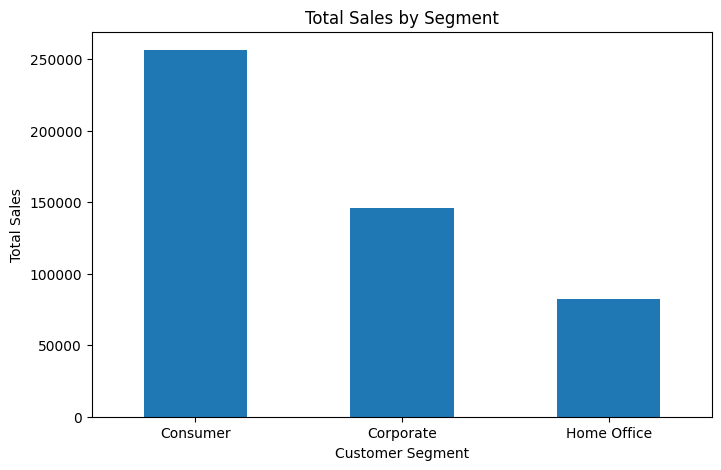

In [63]:
# Visualisasi Total Sales by Customer Segment

sales_by_segment.plot(kind="bar", figsize=(8,5))

plt.title("Total Sales by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.show()


In [69]:
# Total Profit by Customer Segment

profit_by_segment = df.groupby("Customer_Segment")["Profit"].sum().sort_values(ascending=False)

profit_by_segment

Customer_Segment
Consumer       87300.36
Corporate      44463.44
Home Office    27108.52
Name: Profit, dtype: float64

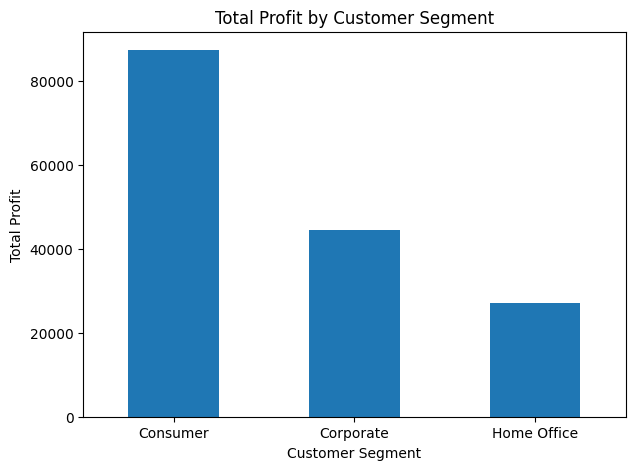

In [66]:
# Visualisasi Total Profit by Customer Segment

profit_by_segment.plot(kind="bar", figsize=(7,5))

plt.title("Total Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Profit")

plt.xticks(rotation=0)

plt.show()

In [67]:
# Profit Margin by Customer Segment

margin_by_segment = df.groupby("Customer_Segment")["Profit_Margin"].mean().sort_values(ascending=False)

margin_by_segment

Customer_Segment
Consumer       0.221340
Home Office    0.197318
Corporate      0.167629
Name: Profit_Margin, dtype: float64

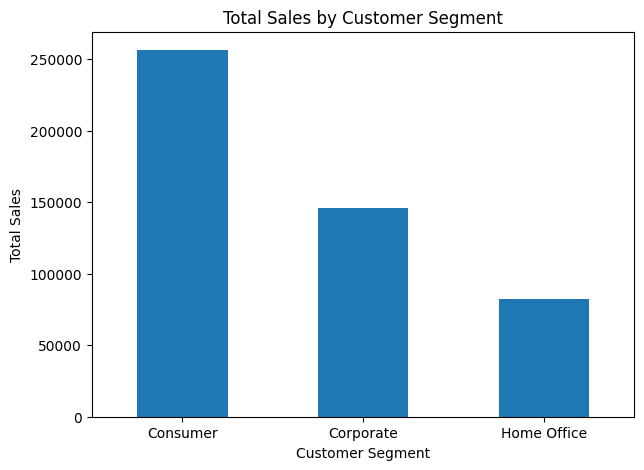

In [68]:
# Visualisasi Profit Margin by Customer Segement

sales_by_segment.plot(kind="bar", figsize=(7,5))

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.show()

Analisis segmentasi pelanggan menunjukkan bahwa segmen Consumer memberikan kontribusi terbesar terhadap total penjualan dan profit serta memiliki tingkat profit margin tertinggi dibandingkan segmen lainnya. Hal ini menunjukkan bahwa segmen Consumer merupakan penggerak utama performa bisnis secara keseluruhan. Segmen Home Office meskipun memiliki kontribusi penjualan yang lebih kecil tetap menunjukkan tingkat profitabilitas yang relatif tinggi sehingga berpotensi menjadi target pengembangan pasar yang menjanjikan. Sebaliknya, segmen Corporate memiliki kontribusi penjualan yang cukup besar namun menunjukkan tingkat margin keuntungan paling rendah, yang mengindikasikan adanya kemungkinan strategi pricing berbasis volume atau kontrak khusus yang menekan profitabilitas pada segmen tersebut.